<a href="https://colab.research.google.com/github/villerbond/avito-text-orientation/blob/main/notebooks/solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Исследование тестовых данных**

In [1]:
from pathlib import Path
import requests
import zipfile
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os
import subprocess
from getpass import getpass

In [2]:
PROJECT_DIR = Path("/content/project")
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
TEST_DIR = PROJECT_DIR / "data" / "test"

TEST_DIR.mkdir(parents=True, exist_ok=True)

print(PROJECT_DIR)

/content/project


Скачиваем архив с тестовыми данными.

In [ ]:
YANDEX_URL = "https://disk.360.yandex.ru/d/ha0Q70T7ie-0_w"
ARCHIVE_PATH = PROJECT_DIR / "data" / "test_data.zip"

def download_yandex_file(public_url, save_path):
    api = "https://cloud-api.yandex.net/v1/disk/public/resources/download"

    download_url = requests.get(
        api,
        params={"public_key": public_url}
    ).json()["href"]

    with requests.get(download_url, stream=True) as r:
        r.raise_for_status()
        with open(save_path, "wb") as f:
            for chunk in r.iter_content(8192):
                f.write(chunk)

    print(f"Saved to {save_path}")


if not ARCHIVE_PATH.exists():
    download_yandex_file(YANDEX_URL, ARCHIVE_PATH)
else:
    print("Archive already exists.")

Saved to /content/project/data/test_data.zip


In [ ]:
print(f"Archive size: {ARCHIVE_PATH.stat().st_size / 1024**2:.1f} MB")

Archive size: 649.9 MB


In [ ]:
if not any(TEST_DIR.iterdir()):
    with zipfile.ZipFile(ARCHIVE_PATH, "r") as z:
        z.extractall(TEST_DIR)
    print("Archive extracted.")
else:
    print("Data already extracted.")

NameError: name 'ARCHIVE_PATH' is not defined

Смотрим структуру распакованного архива.

In [ ]:
files = sorted(TEST_DIR.rglob("*"))

for f in files[:10]:
    print(f.relative_to(TEST_DIR))

sample_submission.csv
test
test/images
test/images/test_00000.png
test/images/test_00001.png
test/images/test_00002.png
test/images/test_00003.png
test/images/test_00004.png
test/images/test_00005.png
test/images/test_00006.png


In [ ]:
image_files = [
    p for p in TEST_DIR.rglob("*")
    if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
]

print(f"Images found: {len(image_files)}")
print(image_files[:5])

Images found: 20000
[PosixPath('/content/project/data/test/test/images/test_16160.png'), PosixPath('/content/project/data/test/test/images/test_16436.png'), PosixPath('/content/project/data/test/test/images/test_11426.png'), PosixPath('/content/project/data/test/test/images/test_08154.png'), PosixPath('/content/project/data/test/test/images/test_04298.png')]


Смотрим случайные примеры текстовых кропов

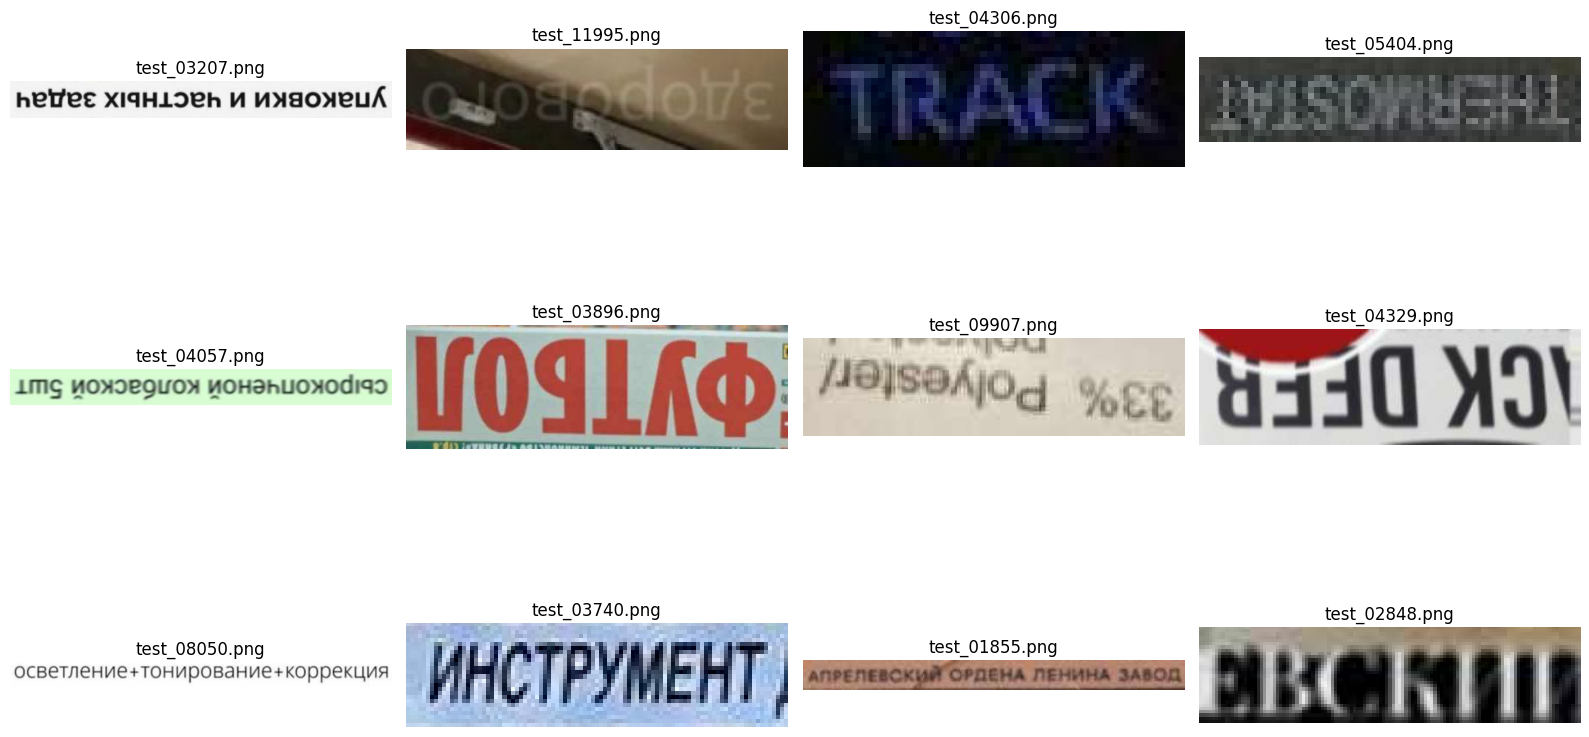

In [ ]:
random.seed(42)

sample_files = random.sample(image_files, 12)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))

for ax, path in zip(axes.ravel(), sample_files):
    ax.imshow(Image.open(path))
    ax.set_title(path.name, fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()

Анализируем размеры изображений

In [ ]:
sizes = []

for path in image_files:
    with Image.open(path) as img:
        sizes.append(img.size)

widths = [w for w, _ in sizes]
heights = [h for _, h in sizes]
ratios = [w / h for w, h in sizes]

print(f"Width : min={min(widths)}, max={max(widths)}, mean={sum(widths)/len(widths):.1f}")
print(f"Height: min={min(heights)}, max={max(heights)}, mean={sum(heights)/len(heights):.1f}")
print(f"Ratio : min={min(ratios):.2f}, max={max(ratios):.2f}, mean={sum(ratios)/len(ratios):.2f}")

Width : min=25, max=1599, mean=357.6
Height: min=10, max=492, mean=64.4
Ratio : min=0.72, max=49.67, mean=6.22


В тестовом наборе содержится 20000 текстовых кропов.

Размеры изображений сильно различаются: ширина изменяется от 25 до 1599 пикселей, а высота - от 10 до 492 пикселей.

Большинство изображений значительно шире своей высоты (среднее отношение сторон около 6.2), что соответствует длинным текстовым строкам.

Такая вариативность размеров означает, что перед подачей изображений в модель потребуется единый этап предобработки - изменение размера изображений. В идеале сохранять пропорции с добавлением паддингом, но сперва можно просто попробовать делать простой resize как baseline, так как задача именно классифицировать ориентацию, а не считывать текст.

# **Обучающие данные**

В тестовых данных встречаются текстовые изображения как с русским, так и с латинским алфавитом.

Для обучения можно использовать готовые датасеты для OCR. Однако для нашей задачи особенно важны датасеты, содержащие уже готовые текстовые кропсы либо позволяющие получить их из размеченных боксов.

На этапе подготовки данных будем рассматривать несколько источников:

* IIIT 5K-Words - содержит готовые crops отдельных слов, однако датасет
относительно небольшой и преимущественно содержит английский текст.
https://www.kaggle.com/datasets/prathmeshzade/iiit5k-words
* MJSynth (Synth90k) - большой синтетический датасет с готовыми crops слов, преимущественно на английском языке.
https://www.kaggle.com/datasets/pradeepsiva/mjsynth-1-250k
* Bilingual OCR RU-EN Synthetic - синтетический датасет с русским и английским текстом.
https://huggingface.co/datasets/tehnik-tehnolog/bilingual-ocr-ru-en-synthetic
* RusTitW - датасет для распознавания русского текста, содержащий как реальные, так и синтетические изображения. Текстовые crops необходимо предварительно извлечь самостоятельно.
https://www.kaggle.com/datasets/hardtype/rustitw-russian-language-visual-text-recognition

Для первого эксперимента выбран RusTitW, поскольку он содержит как реальные, так и синтетические изображения и позволяет получить большое количество текстовых кропсов с русским и латинским текстом.

В датасете есть две части: real - реальные изображения, synth - синтетические изображения.

В обеих частях присутствует разметка текстовых областей. Поэтому сначала необходимо изучить формат info.csv, скачать и посмотреть несколько исходных изображений.

После этого из real и synth можно будет сформировать собственный датасет.

In [ ]:
!pip install -q kaggle

In [ ]:
os.environ["KAGGLE_API_TOKEN"] = getpass("Введите Kaggle API token: ")

Введите Kaggle API token: ··········


In [ ]:
DATA_ROOT = Path("/content/rustitw")
REAL_DIR = DATA_ROOT / "train" / "real"
REAL_IMAGE_DIR = REAL_DIR / "images"

REAL_DIR.mkdir(parents=True, exist_ok=True)
REAL_IMAGE_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
!kaggle datasets download \
    -d hardtype/rustitw-russian-language-visual-text-recognition \
    -f train/real/info.csv \
    -p /content/rustitw/train/real

Dataset URL: https://www.kaggle.com/datasets/hardtype/rustitw-russian-language-visual-text-recognition
License(s): apache-2.0
100% 3.05M/3.05M [00:00<00:00, 72.5MB/s]



In [ ]:
real_zip = REAL_DIR / "info.csv.zip"

with zipfile.ZipFile(real_zip, "r") as z:
    z.extractall(REAL_DIR)

real_zip.unlink()

In [ ]:
real_df = pd.read_csv(REAL_DIR / "info.csv")

print(f"Размер датасета: {real_df.shape[0]:,} изображений")

real_df.head()

Размер датасета: 24,366 изображений


,image_name,box_and_label,width,height,aspect_ratio,text,image_path
0,00001.jpg,"[[{""left"": 0.025925925925925925, ""top"": 0.0074...",1080,1080,1.000000,Мы варим кофе Свежей обжарки\nмила,images/00001.jpg
1,00002.jpg,"[[{""left"": 0.16927083333333334, ""top"": 0.01544...",1920,1295,0.674479,Есть или не Есть вот в чём вопрос,images/00002.jpg
2,00003.jpg,"[[{""left"": 0.10259433962264151, ""top"": 0, ""wid...",848,517,0.609670,ALL you NEED is 20 SECONDS of Insane\nCOURAGE ...,images/00003.jpg
3,00004.jpg,"[[{""left"": 0.008641975308641974, ""top"": 0.0029...",810,1026,1.266667,OLD FASHIONED HOT cocoa\nCOMBINE:\nUNSWEETENED...,images/00004.jpg
4,00005.jpg,"[[{""left"": 0.295, ""top"": 0.1175, ""width"": 0.29...",800,800,1.000000,WHAT'S on TAP!\n ABV \n16 \n5.6 GEORGETOWN - ...,images/00005.jpg


In [ ]:
sample_df = real_df.sample(
    n=3,
    random_state=43
)

In [ ]:
def download_real_image(image_name):
    image_path = REAL_IMAGE_DIR / image_name

    if image_path.exists():
        return image_path

    subprocess.run(
        [
            "kaggle",
            "datasets",
            "download",
            "-d",
            "hardtype/rustitw-russian-language-visual-text-recognition",
            "-f",
            f"train/real/images/{image_name}",
            "-p",
            str(REAL_IMAGE_DIR),
        ],
        check=True,
    )

    return image_path

In [ ]:
for image_name in sample_df["image_name"]:
    download_real_image(image_name)

Посмотрим изображения из датасета

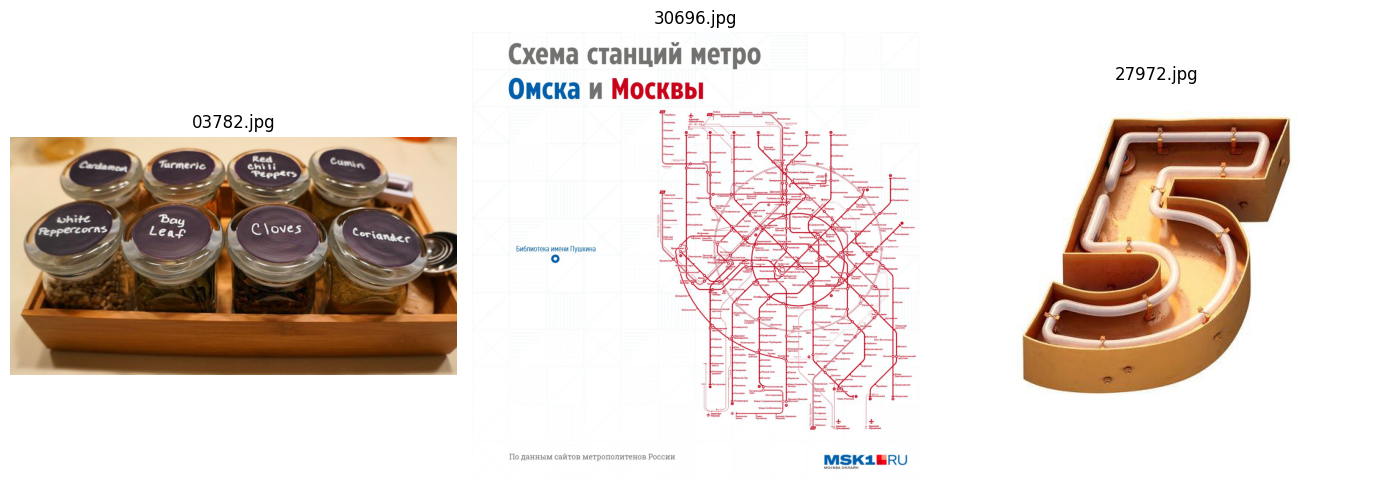

In [ ]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(14, 10)
)

for ax, (_, row) in zip(axes, sample_df.iterrows()):
    image_path = REAL_IMAGE_DIR / row["image_name"]
    image = Image.open(image_path).convert("RGB")

    ax.imshow(image)
    ax.set_title(
        f'{row["image_name"]}'
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

Создаем датасет

Так как объём данных огромный, то создание датасета было выполнено в ноутбуке на kaggle (https://www.kaggle.com/code/villerbond/notebooke8df8f9aa7) и далее загружено на гугл-диск

In [4]:
import gdown

FILE_ID = "1QeKnNsCiVUbwVMz_nHqHwlwnIH2PGQDM"

ARCHIVE_PATH = PROJECT_DIR / "avito_dataset.zip"

gdown.download(
    id=FILE_ID,
    output=str(ARCHIVE_PATH),
    quiet=False
)

Downloading...
From (original): https://drive.google.com/uc?id=1QeKnNsCiVUbwVMz_nHqHwlwnIH2PGQDM
From (redirected): https://drive.google.com/uc?id=1QeKnNsCiVUbwVMz_nHqHwlwnIH2PGQDM&confirm=t&uuid=a4ae7c9c-3893-4031-b548-cc4c45bfc916
To: /content/project/avito_dataset.zip
100%|██████████| 1.60G/1.60G [01:12<00:00, 22.2MB/s]


'/content/project/avito_dataset.zip'

In [5]:
DATASET_DIR = PROJECT_DIR / "avito_dataset"

with zipfile.ZipFile(ARCHIVE_PATH, "r") as z:
    z.extractall(DATASET_DIR)

print("Архив успешно распакован")

Архив успешно распакован


In [6]:
TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR = DATASET_DIR / "val"

train_labels = pd.read_csv(TRAIN_DIR / "labels.csv")
val_labels = pd.read_csv(VAL_DIR / "labels.csv")

print(f"Train: {len(train_labels)}")
print(f"Val: {len(val_labels)}")

Train: 89907
Val: 10093


In [7]:
train_labels.head(5)

,file_name,label
0,crop_0000001.jpg,1
1,crop_0000002.jpg,1
2,crop_0000003.jpg,1
3,crop_0000004.jpg,1
4,crop_0000005.jpg,1


In [8]:
print("Train:")
display(train_labels.groupby("label").size().rename("count"))

print("Val:")
display(val_labels.groupby("label").size().rename("count"))

Train:


,count
label,
0,44937
1,44970


Val:


,count
label,
0,5070
1,5023


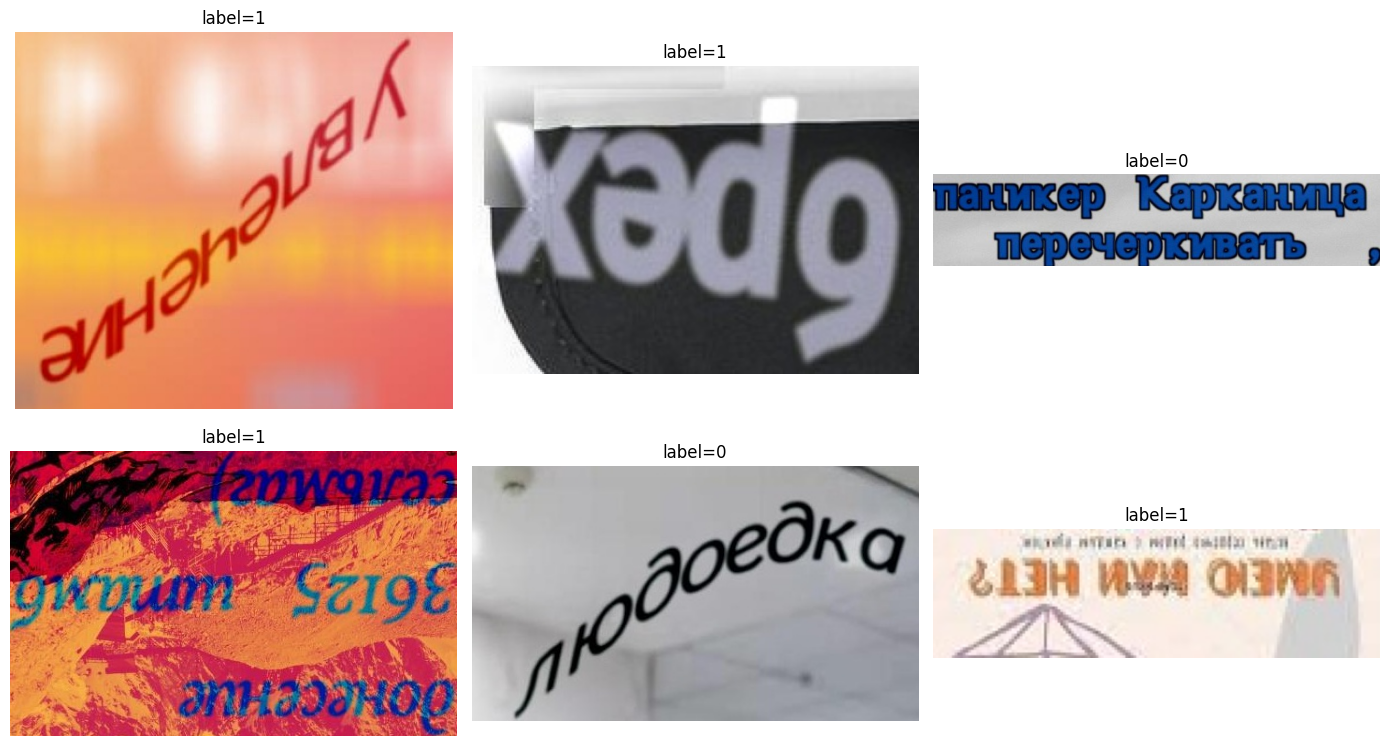

In [ ]:
sample = train_labels.sample(6, random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    img = Image.open(TRAIN_DIR / "crops" / row["file_name"])
    ax.imshow(img)
    ax.set_title(f'label={row["label"]}')
    ax.axis("off")

plt.tight_layout()
plt.show()

Создаем пока простые датасеты и генераторы для первого baseline

In [9]:
import torch
import torchvision

In [10]:
from torchvision import transforms

IMAGE_SIZE = (64, 256)

train_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

val_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

In [11]:
from torch.utils.data import Dataset

class OrientationDataset(Dataset):

    def __init__(self, image_dir, labels_df, transform=None):
        self.image_dir = image_dir
        self.labels = labels_df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        row = self.labels.iloc[idx]

        image = Image.open(self.image_dir / row["file_name"]).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(
            row["label"],
            dtype=torch.float32
        )

        return image, label

In [12]:
train_dataset = OrientationDataset(
    TRAIN_DIR / "crops",
    train_labels,
    train_transform
)

val_dataset = OrientationDataset(
    VAL_DIR / "crops",
    val_labels,
    val_transform
)

print(len(train_dataset))
print(len(val_dataset))

89907
10093


In [13]:
image, label = train_dataset[0]

print(image.shape)
print(label)

torch.Size([3, 64, 256])
tensor(1.)


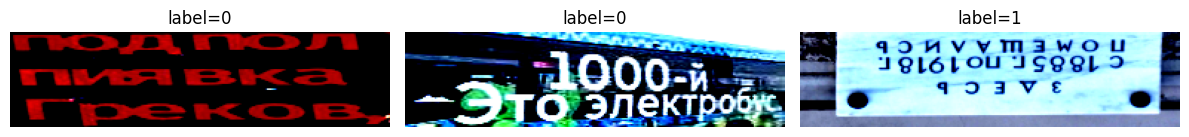

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 8))

for ax in axes.flat:

    idx = random.randint(0, len(train_dataset) - 1)

    image, label = train_dataset[idx]

    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(f"label={int(label)}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [14]:
from torch.utils.data import DataLoader

BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

In [15]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([128, 3, 64, 256])
torch.Size([128])


# **Создание модели и функции для обучения**

Задача проще, чем распознавание текста, и плюс в условии требуется компактность и скорость, поэтому больше подойдут быстрые небольшие модели

*   Кастомная CNN
*   ResNet18
*   EfficientNet-B0
*   MobileNetV3 Small
*   ShuffleNetV2 (x1.0)

In [16]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [17]:
from tqdm.auto import tqdm

def train_one_epoch(model, loader, criterion, optimizer, device, epoch, epochs):

    model.train()
    running_loss = 0

    progress = tqdm(loader, leave=False, desc=f"Epoch {epoch}/{epochs} [Train]")

    for images, labels in progress:

        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    progress.close()
    return running_loss / len(loader)

In [18]:
from sklearn.metrics import brier_score_loss

def validate(model, loader, criterion, device, epoch, epochs):

    model.eval()

    running_loss = 0

    probabilities = []
    targets = []

    progress = tqdm(loader, leave=False, desc=f"Epoch {epoch}/{epochs} [Val]")

    with torch.no_grad():

        for images, labels in progress:

            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            probs = torch.sigmoid(outputs)

            probabilities.extend(probs.cpu().numpy().flatten())
            targets.extend(labels.cpu().numpy().flatten())

    progress.close()
    val_loss = running_loss / len(loader)
    brier = brier_score_loss(targets, probabilities)

    return {
        "loss": val_loss,
        "score": 1 - brier
    }

In [19]:
def fit_model(model, train_loader, val_loader, criterion, optimizer, device, epochs):

    history = []

    for epoch in range(epochs):

        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device, epoch + 1, epochs)
        metrics = validate(model, val_loader, criterion, device, epoch + 1, epochs)

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": metrics["loss"],
            "val_score": metrics["score"]
        })


    history_df = pd.DataFrame(history)
    return model, history_df

In [31]:
def plot_results(history_df):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(
        history_df["epoch"],
        history_df["train_loss"],
        marker="o",
        label="Train"
    )
    plt.plot(
        history_df["epoch"],
        history_df["val_loss"],
        marker="o",
        label="Validation"
    )
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(
        history_df["epoch"],
        history_df["val_score"],
        marker="o"
    )
    plt.title("Score")
    plt.xlabel("Epoch")
    plt.ylabel("1 - Brier Score")

    plt.tight_layout()
    plt.show()

Обучим несколько моделей на небольшом количестве эпох, посмотрим на результаты

**ResNet18**

In [23]:
import torch.nn as nn

In [ ]:
from torchvision.models import resnet18, ResNet18_Weights

weights = ResNet18_Weights.DEFAULT
model_resnet18 = resnet18(weights=weights)
model_resnet18.fc = nn.Linear(model_resnet18.fc.in_features, 1)

model_resnet18 = model_resnet18.to(device)

In [ ]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_resnet18.parameters(), lr=1e-4)

In [ ]:
model_resnet18, history_df_resnet18 = fit_model(model_resnet18, train_loader, val_loader, criterion, optimizer, device, epochs=10)

Epoch 1/10 [Train]:   0%|          | 0/703 [00:00<?, ?it/s]

Epoch 1/10 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 2/10 [Train]:   0%|          | 0/703 [00:00<?, ?it/s]

Epoch 2/10 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 3/10 [Train]:   0%|          | 0/703 [00:00<?, ?it/s]

...

Epoch 8/10 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 9/10 [Train]:   0%|          | 0/703 [00:00<?, ?it/s]

Epoch 9/10 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 10/10 [Train]:   0%|          | 0/703 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

In [ ]:
history_df_resnet18

,epoch,train_loss,val_loss,val_score
0,1,0.460566,0.328002,0.893911
1,2,0.233065,0.284042,0.910655
2,3,0.127653,0.281843,0.916727
3,4,0.076709,0.282492,0.921476
4,5,0.050597,0.322254,0.915904
5,6,0.043397,0.436887,0.899079
6,7,0.036379,0.409775,0.907879
7,8,0.028593,0.382692,0.912917
8,9,0.028739,0.353474,0.920943
9,10,0.024835,0.366011,0.917537


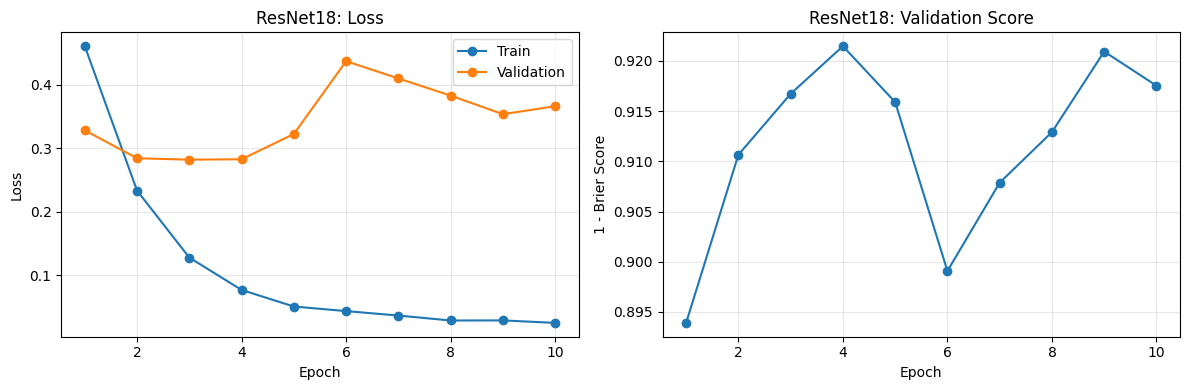

In [ ]:
plot_results(history_df_resnet18)

**EfficientNet-B0**

In [24]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

model_efficientnet = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

model_efficientnet.classifier[1] = nn.Linear(
    model_efficientnet.classifier[1].in_features,
    1
)

model_efficientnet = model_efficientnet.to(device)

In [25]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_efficientnet.parameters(), lr=1e-4)

In [26]:
model_efficientnet, history_df_efficientnet = fit_model(model_efficientnet, train_loader, val_loader, criterion, optimizer, device, epochs=10)

Epoch 1/10 [Train]:   0%|          | 0/703 [00:00<?, ?it/s]

Epoch 1/10 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 2/10 [Train]:   0%|          | 0/703 [00:00<?, ?it/s]

Epoch 2/10 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 3/10 [Train]:   0%|          | 0/703 [00:00<?, ?it/s]

...

Epoch 8/10 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 9/10 [Train]:   0%|          | 0/703 [00:00<?, ?it/s]

Epoch 9/10 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 10/10 [Train]:   0%|          | 0/703 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

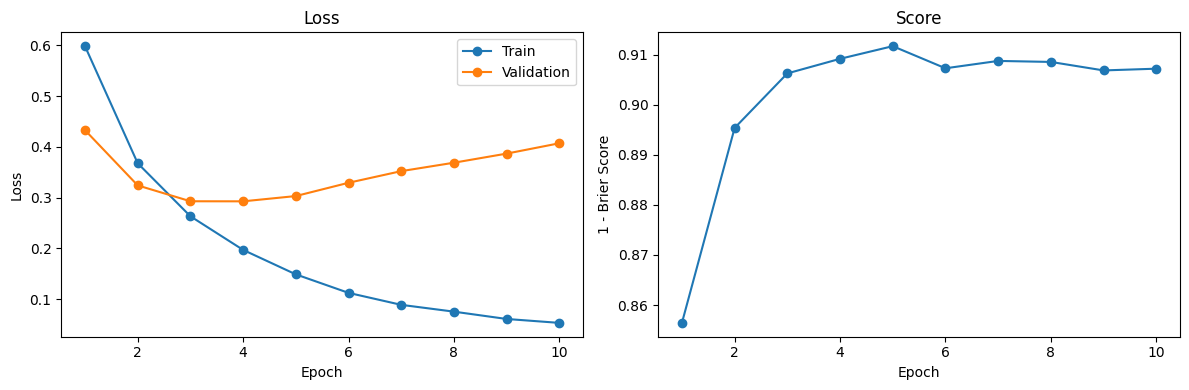

In [32]:
plot_results(history_df_efficientnet)

**MobileNetV3 Small**

In [ ]:
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights

model_mobilenet = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.DEFAULT)

model_mobilenet.classifier[3] = nn.Linear(
    model_mobilenet.classifier[3].in_features,
    1
)

model_mobilenet = model_mobilenet.to(device)

Exception ignored in: <function tqdm.__del__ at 0x79890968f100>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/usr/local/lib/python3.13/dist-packages/tqdm/notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm' object has no attribute 'disp'


In [ ]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_mobilenet.parameters(), lr=1e-4)

In [ ]:
model_mobilenet, history_df_mobilenet = fit_model(model_mobilenet, train_loader, val_loader, criterion, optimizer, device, epochs=10)

Epoch 1/10 [Train]:   0%|          | 0/703 [00:00<?, ?it/s]

Epoch 1/10 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 2/10 [Train]:   0%|          | 0/703 [00:00<?, ?it/s]

Epoch 2/10 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 3/10 [Train]:   0%|          | 0/703 [00:00<?, ?it/s]

...

Epoch 8/10 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 9/10 [Train]:   0%|          | 0/703 [00:00<?, ?it/s]

Epoch 9/10 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 10/10 [Train]:   0%|          | 0/703 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

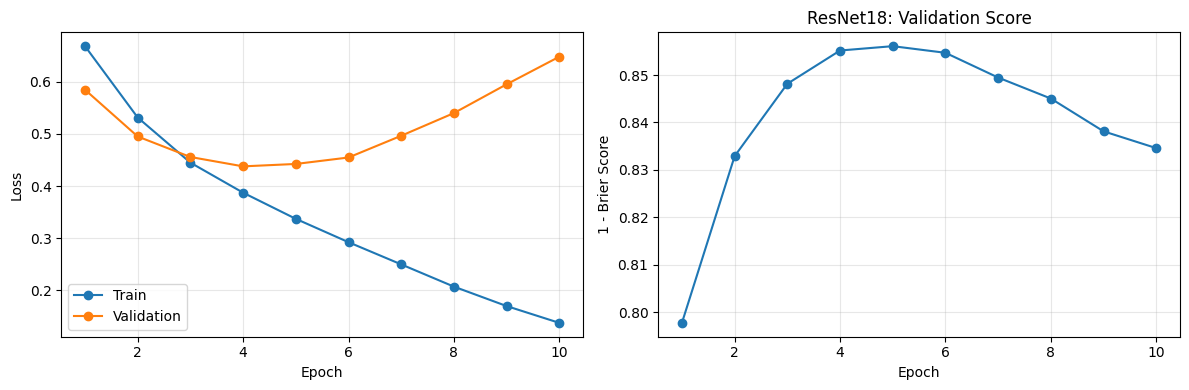

In [ ]:
plot_results(history_df_mobilenet)

**ShuffleNetV2 (x1.0)**

In [28]:
from torchvision.models import shufflenet_v2_x1_0, ShuffleNet_V2_X1_0_Weights

model_shufflenet = shufflenet_v2_x1_0(weights=ShuffleNet_V2_X1_0_Weights.DEFAULT)

model_shufflenet.fc = nn.Linear(
    model_shufflenet.fc.in_features,
    1
)

model_shufflenet = model_shufflenet.to(device)

Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to /root/.cache/torch/hub/checkpoints/shufflenetv2_x1-5666bf0f80.pth


100%|██████████| 8.79M/8.79M [00:00<00:00, 61.6MB/s]


In [29]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_shufflenet.parameters(), lr=1e-4)

In [30]:
model_shufflenet, history_df_shufflenet = fit_model(model_shufflenet, train_loader, val_loader, criterion, optimizer, device, epochs=10)

Epoch 1/10 [Train]:   0%|          | 0/703 [00:00<?, ?it/s]

Epoch 1/10 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 2/10 [Train]:   0%|          | 0/703 [00:00<?, ?it/s]

Epoch 2/10 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 3/10 [Train]:   0%|          | 0/703 [00:00<?, ?it/s]

...

Epoch 8/10 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 9/10 [Train]:   0%|          | 0/703 [00:00<?, ?it/s]

Epoch 9/10 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 10/10 [Train]:   0%|          | 0/703 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/79 [00:00<?, ?it/s]

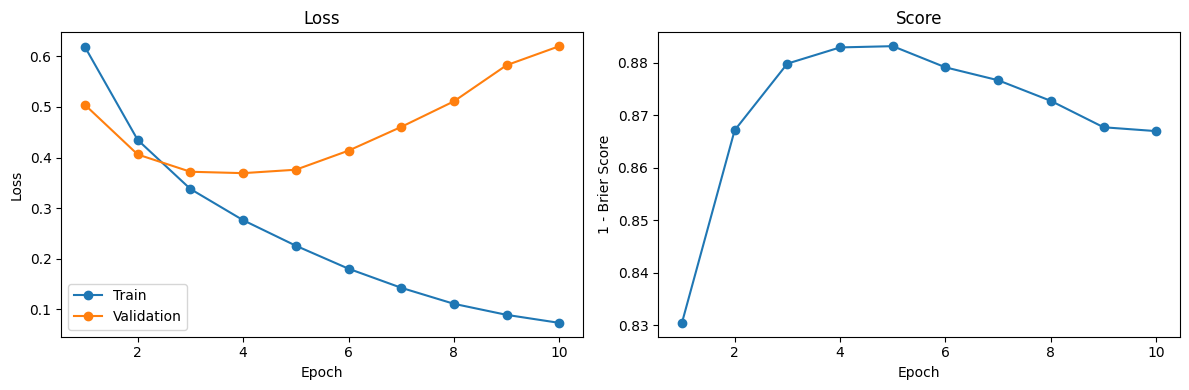

In [34]:
plot_results(history_df_shufflenet)

**Кастомная простая модель**

In [ ]:
class SimpleCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d(1)
        )

        self.classifier = nn.Linear(128, 1)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.classifier(x)

In [ ]:
model_cnn = SimpleCNN().to(device)

In [ ]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=1e-4)

In [ ]:
model_cnn, history_df_cnn = fit_model(model_cnn, train_loader, val_loader, criterion, optimizer, device, epochs=10)